<a href="https://colab.research.google.com/github/entropy-om/entheai/blob/rahul-phi-work/Rahul_rangarao_phi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch unsloth transformers datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.1/76.1 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 153.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 90.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 93.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 113.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.0/215.0 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 116.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/

In [2]:
!pip install peft bitsandbytes trl accelerate

In [3]:
# Install a font that supports a wide range of Unicode characters (e.g., WenQuanYi Zen Hei CJK font)
!sudo apt-get install -y fonts-wqy-zenhei

# Clear matplotlib's font cache
import matplotlib.font_manager as fm
fm._load_fontmanager(try_read_cache=False)

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-wqy-zenhei
0 upgraded, 1 newly installed, 0 to remove and 53 not upgraded.
Need to get 7,472 kB of archives.
After this operation, 16.8 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-wqy-zenhei all 0.9.45-8 [7,472 kB]
Fetched 7,472 kB in 4s (1,967 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-wqy-zenhei.
(Reading database ... 12240

## Local Inference on GPU
Model page: https://huggingface.co/microsoft/Phi-4-mini-instruct

What im trying to do:

In [1]:
from transformers import pipeline
from torch import nn
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
import matplotlib.pyplot as plt
import numpy as np
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
tokenizer = AutoTokenizer.from_pretrained("microsoft/Phi-4-mini-instruct")

model_id = "microsoft/Phi-4-mini-instruct"
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id, quantization_config=bnb_config, device_map="auto"
    ,torch_dtype="auto",       # bf16 → ~7.7 GB instead of ~15 GB
    torch_dtype=torch.bfloat16

)

This model config has set a `rope_parameters['original_max_position_embeddings']` field, to be used together with `max_position_embeddings` to determine a scaling factor. Please set the `factor` field of `rope_parameters`with this ratio instead -- we recommend the use of this field over `original_max_position_embeddings`, as it is compatible with most model architectures.


Loading weights:   0%|          | 0/194 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


In [14]:
print(model.lm_head)  # Linear(in_features=hidden_size, out_features=vocab_size, bias=False)

# Freeze the backbone — only train the new head
for param in model.model.parameters():
    param.requires_grad = False

hidden_size = model.config.hidden_size
vocab_size = model.config.vocab_size

Linear(in_features=3072, out_features=200064, bias=False)


In [15]:
class CustomLMHead(nn.Module):
    def __init__(self, hidden_size, vocab_size):
        super().__init__()
        self.proj1 = nn.Linear(hidden_size, hidden_size)
        self.act = nn.GELU()
        self.norm = nn.LayerNorm(hidden_size)
        self.proj2 = nn.Linear(hidden_size, vocab_size, bias=False)

    def forward(self, hidden_states):
        # Ensure hidden_states match the weight dtype (e.g., BFloat16)
        dtype = self.proj1.weight.dtype
        x = hidden_states.to(dtype)
        x = self.act(self.proj1(x))
        x = self.norm(x)
        return self.proj2(x)

# Re-apply the head to the model
model.lm_head = CustomLMHead(hidden_size, vocab_size).to(device=model.device, dtype=torch.bfloat16)

In [25]:
def generate_with_custom_sampling(model, tokenizer, prompt, max_new_tokens=50,
                                    temperature=0.8, top_k=42, top_p=0.8,
                                    repetition_penalty=1.1):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    generated = inputs["input_ids"]
    step_probs = [] # To store the probability of the chosen token at each step

    for _ in range(max_new_tokens):
        with torch.no_grad():
            outputs = model(generated)
            logits = outputs.logits[:, -1, :]

        logits = logits / temperature

        for token_id in set(generated[0].tolist()):
            logits[0, token_id] /= repetition_penalty

        top_k_vals, top_k_idx = torch.topk(logits, top_k)
        filtered = torch.full_like(logits, float("-inf"))
        filtered.scatter_(1, top_k_idx, top_k_vals)

        probs = torch.softmax(filtered, dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)

        # Capture the probability of the token that was actually picked
        actual_prob = probs[0, next_token.item()].item()
        step_probs.append(actual_prob)

        generated = torch.cat([generated, next_token], dim=1)
        if next_token.item() == tokenizer.eos_token_id:
            break

    return tokenizer.decode(generated[0], skip_special_tokens=False), probs, generated, step_probs

In [26]:
messages = [
      {"role": "user", "content": "Who are you? Who am I?"},
  ]

inputs = tokenizer.apply_chat_template(
      messages,
      add_generation_prompt=True,
      tokenize=True,
      return_dict=True,
      return_tensors="pt",
  ).to(model.device)

In [27]:
outputs = model.generate(**inputs, max_new_tokens=40)
print(tokenizer.decode(outputs[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True))

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


I am Phi, an AI developed by Microsoft. You are a user interacting with me. How can I assist you today?


It is definitely gibberish, It needs to be trained on "Rahul"

In [28]:
all_data_distri, last_step_probs, generated, token_probs = generate_with_custom_sampling(model, tokenizer, prompt=messages[0]['content'])

# Prepare data for DataFrame
prompt_len = tokenizer(messages[0]['content'], return_tensors="pt")["input_ids"].shape[1]
gen_tokens = generated[0][prompt_len:]

data = []
for i, (t_id, p) in enumerate(zip(gen_tokens, token_probs)):
    data.append({
        'position': i,
        'token_id': t_id.item(),
        'token_text': tokenizer.decode([t_id]),
        'probability': p
    })

df_results = pd.DataFrame(data)
display(df_results)

,position,token_id,token_text,probability
0,0,1958,And,0.010132
1,1,4436,why,0.357422
2,2,621,do,0.554688
3,3,1879,these,0.102051
4,4,5359,questions,0.953125
5,5,7165,matter,0.699219
6,6,1261,when,0.070312
7,7,480,it,0.267578
8,8,5124,comes,1.000000
9,9,316,to,1.000000


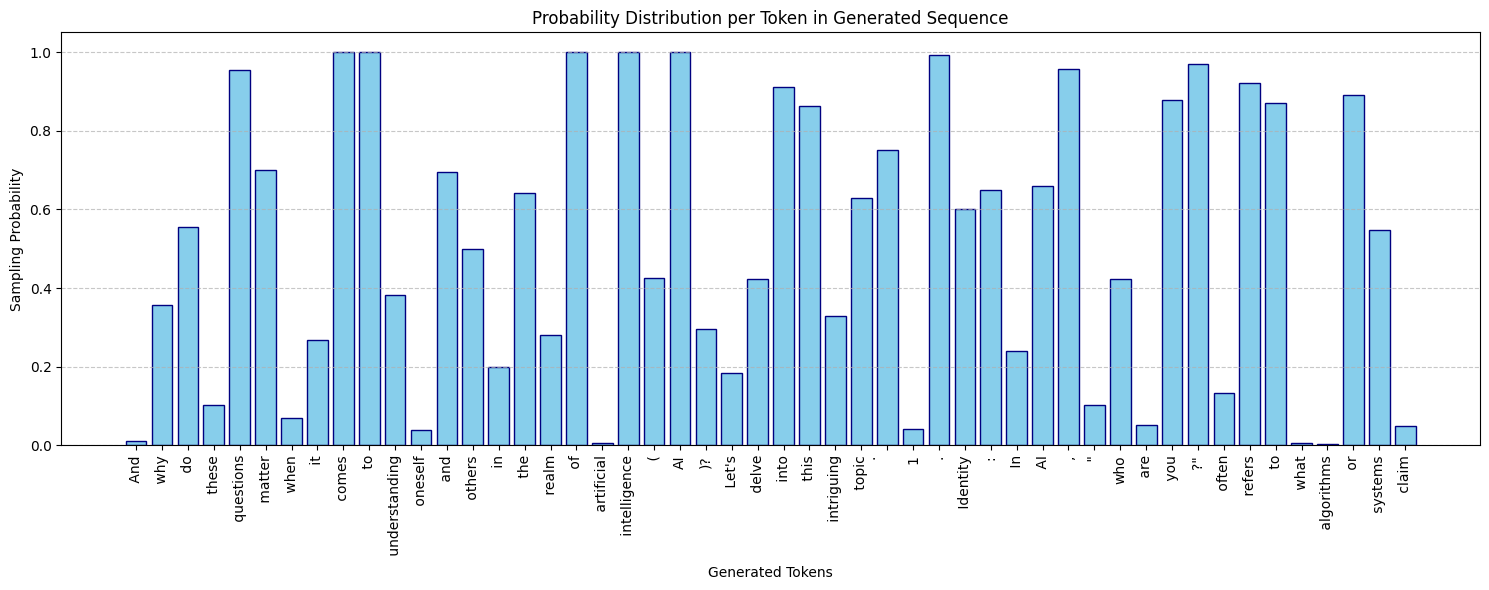

In [29]:
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='matplotlib.font_manager')

plt.figure(figsize=(15, 6))
plt.bar(df_results['position'], df_results['probability'], color='skyblue', edgecolor='navy')
plt.xticks(df_results['position'], df_results['token_text'], rotation=90)
plt.xlabel('Generated Tokens')
plt.ylabel('Sampling Probability')
plt.title('Probability Distribution per Token in Generated Sequence')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [30]:
all_data_distri

'Who are you? Who am I? And why do these questions matter when it comes to understanding oneself and others in the realm of artificial intelligence (AI)? Let\'s delve into this intriguing topic.\n\n1. Identity: In AI, "who are you?" often refers to what algorithms or systems claim'

In [31]:
len(gen_tokens)==len(token_probs)

True

In [32]:
print(last_step_probs[last_step_probs > 0])

tensor([0.0040, 0.0295, 0.0015, 0.0015, 0.0009, 0.2178, 0.1318, 0.0295, 0.0009,
        0.0024, 0.0015, 0.0024, 0.0024, 0.0066, 0.0040, 0.0066, 0.0295, 0.0179,
        0.0015, 0.0015, 0.0024, 0.0024, 0.0040, 0.0179, 0.0009, 0.0066, 0.0040,
        0.0486, 0.0024, 0.0009, 0.0024, 0.3594, 0.0066, 0.0179, 0.0009, 0.0024,
        0.0040, 0.0009, 0.0009, 0.0179, 0.0015, 0.0015], device='cuda:0',
       dtype=torch.bfloat16)


In [33]:
last_step_probs[last_step_probs>0]

tensor([0.0040, 0.0295, 0.0015, 0.0015, 0.0009, 0.2178, 0.1318, 0.0295, 0.0009,
        0.0024, 0.0015, 0.0024, 0.0024, 0.0066, 0.0040, 0.0066, 0.0295, 0.0179,
        0.0015, 0.0015, 0.0024, 0.0024, 0.0040, 0.0179, 0.0009, 0.0066, 0.0040,
        0.0486, 0.0024, 0.0009, 0.0024, 0.3594, 0.0066, 0.0179, 0.0009, 0.0024,
        0.0040, 0.0009, 0.0009, 0.0179, 0.0015, 0.0015], device='cuda:0',
       dtype=torch.bfloat16)

Actual finetuning starts here!


In [9]:
from peft import LoraConfig, prepare_model_for_kbit_training

tokenizer = AutoTokenizer.from_pretrained("microsoft/Phi-4-mini-instruct")

model_id = "microsoft/Phi-4-mini-instruct"
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id, quantization_config=bnb_config, device_map="auto"
    ,torch_dtype=torch.bfloat16,       # bf16 → ~7.7 GB instead of ~15 GB

)

model = prepare_model_for_kbit_training(model)
lora_config = LoraConfig(
    r=16, lora_alpha=32, lora_dropout=0.05,
    target_modules=["qkv_proj", "o_proj", "gate_up_proj", "down_proj"],
    task_type="CAUSAL_LM",
)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/194 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


In [10]:
from datasets import load_dataset

data = load_dataset("json", data_files={
    "train": "/content/drive/MyDrive/Colab Notebooks/rahul-ai/train.jsonl",
    "validation": "/content/drive/MyDrive/Colab Notebooks/rahul-ai/valid.jsonl",
    "test": "/content/drive/MyDrive/Colab Notebooks/rahul-ai/test.jsonl",
})

In [11]:
from trl import SFTTrainer, SFTConfig

Going back to the original once more

In [16]:
# Re-apply preparation and custom head since the model was re-initialized
model = prepare_model_for_kbit_training(model)
model.lm_head = CustomLMHead(hidden_size, vocab_size).to(device=model.device, dtype=torch.bfloat16)

In [17]:
sft_config = SFTConfig(
    output_dir="/content/adapters",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    num_train_epochs=50,
    learning_rate=1e-4,
    eval_strategy="steps",
    eval_steps=25,
    logging_steps=10,
    bf16=True,
    packing=False,
)

In [18]:
trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=data["train"],
    eval_dataset=data["test"],
    peft_config=lora_config,
)
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
25,11.812897,11.109569,11.921792,131829.000000,0.107866
50,9.723686,9.777345,11.240575,257575.000000,0.157784
75,8.854862,8.827270,10.410166,387760.000000,0.228079
100,7.888678,8.250093,9.899548,519179.000000,0.276945
125,7.502598,7.890310,9.645599,648047.000000,0.301250
150,7.069311,7.700040,9.315917,775520.000000,0.321389
175,6.781092,7.592627,9.092464,906562.000000,0.338403
200,6.533378,7.529372,8.886905,1036013.000000,0.344309
225,6.336280,7.516232,8.910025,1163280.000000,0.342740
250,6.122168,7.449972,8.764105,1293232.000000,0.349137


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


TrainOutput(global_step=750, training_loss=6.0671384785970055, metrics={'train_runtime': 1811.1761, 'train_samples_per_second': 3.258, 'train_steps_per_second': 0.414, 'total_flos': 1.2152996078410138e+17, 'train_loss': 6.0671384785970055, 'epoch': 50.0})

In [21]:
messages = [
      {"role": "user", "content": "Who are you? Who am I?"},
  ]

inputs = tokenizer.apply_chat_template(
      messages,
      add_generation_prompt=True,
      tokenize=True,
      return_dict=True,
      return_tensors="pt",
  ).to(device=model.device)

In [22]:
outputs = model.generate(**inputs, max_new_tokens=40)
print(tokenizer.decode(outputs[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True))

RuntimeError: expected scalar type BFloat16 but found Float

custom experimentation...

In [ ]:
model.lm_head = CustomLMHead(hidden_size, vocab_size).to(device=model.device, dtype=torch.bfloat16)

In [ ]:
def generate_with_custom_sampling(model, tokenizer, prompt, max_new_tokens=50,
                                    temperature=0.8, top_k=42, top_p=0.8,
                                    repetition_penalty=1.1):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    generated = inputs["input_ids"]
    step_probs = [] # To store the probability of the chosen token at each step

    for _ in range(max_new_tokens):
        with torch.no_grad():
            outputs = model(generated)
            logits = outputs.logits[:, -1, :]

        logits = logits / temperature

        for token_id in set(generated[0].tolist()):
            logits[0, token_id] /= repetition_penalty

        top_k_vals, top_k_idx = torch.topk(logits, top_k)
        filtered = torch.full_like(logits, float("-inf"))
        filtered.scatter_(1, top_k_idx, top_k_vals)

        probs = torch.softmax(filtered, dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)

        # Capture the probability of the token that was actually picked
        actual_prob = probs[0, next_token.item()].item()
        step_probs.append(actual_prob)

        generated = torch.cat([generated, next_token], dim=1)
        if next_token.item() == tokenizer.eos_token_id:
            break

    return tokenizer.decode(generated[0], skip_special_tokens=False), probs, generated, step_probs

In [34]:

all_data_distri, last_step_probs, generated, token_probs = generate_with_custom_sampling(model, tokenizer, prompt=messages[0]['content'])

# Prepare data for DataFrame
prompt_len = tokenizer(messages[0]['content'], return_tensors="pt")["input_ids"].shape[1]
gen_tokens = generated[0][prompt_len:]

data_list = []
for i, (t_id, p) in enumerate(zip(gen_tokens, token_probs)):
    data_list.append({
        'position': i,
        'token_id': t_id.item(),
        'token_text': tokenizer.decode([t_id]),
        'probability': p
    })

df_results = pd.DataFrame(data_list)
display(df_results)

RuntimeError: expected mat1 and mat2 to have the same dtype, but got: float != c10::BFloat16

In [29]:
all_data_distri

'Who are you? Who am I? Chapel rooft QPoint felly forb اش möj/plainន្ល-edfügbłę以 legge राज्यों identiteit Poly lojestos AguilParas fehlen Leider girls养官方网址ოდისవి competing аҳәа মহান removes identiteitzustalore maje támogatіс اړه болestruct leedxmlnsოდისіс françaises legge Sharon(heroଆ'

Loading weights:   0%|          | 0/194 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
